# Extension Step 1 — Recipe Step Localization with ActionFormer

Loads the ActionFormer checkpoint trained in Substep 1a, tunes post-processing on the
validation split, reports localization on the held-out test split once, and exports step
embeddings for Substeps 2-4.

### Canonical prediction variables
- `predictions_actionformer_raw`: **immutable** checkpoint output. Never overwritten.
- `predictions_actionformer_final`: validation-selected post-processed output.

### Clean experiment flow
1. Load data and verify the EgoVLP time base.
2. Run/load ActionFormer checkpoint inference → raw predictions.
3. Define post-processing/evaluation helpers once.
4. Tune score threshold + class-agnostic NMS + minimum duration on **validation only**.
5. Freeze the best configuration and create final predictions.
6. Run a **component ablation** on the test split (raw / score / NMS / duration / full).
7. Visualize, evaluate, and export embeddings using the canonical final predictions.




In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Base paths
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    CODE_BASE = "/content/code"

    # Clone Main Repository (if not exists)
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists(CODE_BASE):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} {CODE_BASE}
        os.chdir(CODE_BASE)
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir(CODE_BASE)

    if CODE_BASE not in sys.path:
        sys.path.append(CODE_BASE)

    # Install requirements
    !pip install -q torcheval

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")
    DRIVE_BASE = "."
    CODE_BASE = os.getcwd()

# Substep 1 writes to two places, and the distinction matters.
#
# STEP1_RESULTS_DIR   this notebook's own artefacts: raw predictions, the tuning and
#                     ablation tables, the figures. Nothing downstream reads them.
# EXTENSION_DATA_DIR  the pipeline handoff. Substeps 2, 3 and 4 read `extension_data/`
#                     and nowhere else, so the two step-embedding pickles must land
#                     there or the later notebooks silently consume a stale export.
STEP1_RESULTS_DIR = os.path.join(DRIVE_BASE, "step_1_results_final")
os.makedirs(STEP1_RESULTS_DIR, exist_ok=True)

EXTENSION_DATA_DIR = os.path.join(DRIVE_BASE, "extension_data")
os.makedirs(EXTENSION_DATA_DIR, exist_ok=True)

# In Colab the pipeline notebooks look on Drive first and fall back to a local
# extension_data/ inside the cloned repo; writing both keeps either path working.
LOCAL_EXTENSION_DIR = os.path.join(CODE_BASE, "extension_data") if IN_COLAB else "extension_data"
os.makedirs(LOCAL_EXTENSION_DIR, exist_ok=True)

print(f"Step 1 artefacts : {STEP1_RESULTS_DIR}")
print(f"Pipeline handoff : {EXTENSION_DATA_DIR}")
print(f"                   {LOCAL_EXTENSION_DIR}")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PATHS ---
if IN_COLAB:
    EGOVLP_FEATURE_DIR = os.path.join(DRIVE_BASE, "features/egovlp")
else:
    EGOVLP_FEATURE_DIR = "data/features/egovlp"

ANNOTATION_PATH = "annotations/annotation_json/step_annotations.json"


print(f"EgoVLP Features: {EGOVLP_FEATURE_DIR}")
print(f"Annotations: {ANNOTATION_PATH}")

Running in Google Colab
Mounted at /content/drive
Cloning repository from https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git...
Cloning into '/content/code'...
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 952 (delta 118), reused 112 (delta 96), pack-reused 786 (from 2)
Receiving objects: 100% (952/952), 97.86 MiB | 19.40 MiB/s, done.
Resolving deltas: 100% (508/508), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 18.03 MiB/s, done.
Resolving deltas: 100% (75/75), done.
S

## 1. Load Data and Annotations

Load the EgoVLP features and ground truth step boundaries for training.

In [2]:
import os
import json
import urllib.request

# Official ActionFormer recording split
ANN_DIR = "/content/captaincook_annotations"
os.makedirs(ANN_DIR, exist_ok=True)

SPLIT_PATH = os.path.join(ANN_DIR, "recordings.json")

SPLIT_URL = (
    "https://raw.githubusercontent.com/"
    "CaptainCook4D/multi_step_localization/main/"
    "captaincook_actionformer_annotations/combined/recordings.json"
)

if not os.path.isfile(SPLIT_PATH):
    print("Downloading ActionFormer split...")
    urllib.request.urlretrieve(SPLIT_URL, SPLIT_PATH)

print("ActionFormer split:", SPLIT_PATH)

with open(SPLIT_PATH, "r") as f:
    actionformer_data = json.load(f)

db = actionformer_data["database"]

splits = {
    "train": [
        rid for rid, info in db.items()
        if info["subset"].lower() == "training"
    ],
    "val": [
        rid for rid, info in db.items()
        if info["subset"].lower() == "validation"
    ],
    "test": [
        rid for rid, info in db.items()
        if info["subset"].lower() == "test"
    ],
}

print("Train:", len(splits["train"]))
print("Val:", len(splits["val"]))
print("Test:", len(splits["test"]))


ActionFormer split: /content/captaincook_annotations/recordings.json
Train: 213
Val: 62
Test: 109


In [3]:
# Load annotations
with open(ANNOTATION_PATH, 'r') as f:
    step_annotations = json.load(f)


print(f"Total recordings: {len(step_annotations)}")
print(f"Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

# Helper to load features
def load_features(recording_id, feature_dir=EGOVLP_FEATURE_DIR):
    """Load EgoVLP features for a recording."""
    path = os.path.join(feature_dir, f"{recording_id}_360p_224.npz")
    if os.path.exists(path):
        data = np.load(path)
        return data[list(data.keys())[0]]
    return None

# Check feature availability
available_recordings = []
for rec_id in step_annotations.keys():
    if load_features(rec_id) is not None:
        available_recordings.append(rec_id)

print(f"Recordings with available features: {len(available_recordings)}/{len(step_annotations)}")

Total recordings: 384
Train: 213, Val: 62, Test: 109
Recordings with available features: 384/384


In [4]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Feature time base: EgoVLP features are extracted with a 1s window and 1s
# stride (SEGMENT_LENGTH = 1 in colab_feature_extraction.ipynb), so there is
# exactly one feature row per second and row i corresponds to second i.
#
# FEATURE_FPS must track the feature extraction stride: at the wrong value, a
# step's pooling window covers the wrong range of rows, and in the worst case
# only ever reads the first half of each recording. If features are ever
# re-extracted at a different stride, this constant must change with them.
FEATURE_FPS = 1.0
print(f"\nUsing Feature FPS: {FEATURE_FPS} (1 feature per second)")



Using Feature FPS: 1.0 (1 feature per second)


In [5]:
# ==============================================================================
# SANITY CHECK: feature rows vs. annotation timestamps (time-base guard)
# ==============================================================================
# Feature rows and step annotations must share a time base: row i must
# correspond to second i / FEATURE_FPS. Nothing enforces that automatically -
# numpy returns an EMPTY slice for an out-of-range index rather than raising,
# so a mismatch shows up as silently-wrong embeddings, not as an error. Run
# this before training; it fails loudly instead.

def check_feature_time_base(recording_ids, fps=None, verbose=True):
    """Assert every recording has enough feature rows to cover its last step."""
    fps = FEATURE_FPS if fps is None else fps
    too_short, ratios, checked = [], [], 0

    for rec_id in recording_ids:
        features = load_features(rec_id)
        if features is None:
            continue
        steps = step_annotations[rec_id]['steps']
        ends = [float(s['end_time']) for s in steps if float(s['end_time']) >= 0]
        if not ends:
            continue
        n_rows, last_end = len(features), max(ends)
        needed = last_end * fps           # rows required to reach the last step
        checked += 1
        ratios.append(n_rows / max(needed, 1e-9))
        if n_rows + 1 < needed:           # +1 absorbs floor/rounding at the tail
            too_short.append((rec_id, n_rows, last_end, needed))

    if verbose:
        print(f"Time-base check at FEATURE_FPS={fps} - {checked} recordings")
        if ratios:
            print(f"  rows / rows-needed:  min={min(ratios):.3f}  "
                  f"median={sorted(ratios)[len(ratios)//2]:.3f}  max={max(ratios):.3f}")
            print(f"  (expect >= 1.00; a value near 0.50 means the features are on a "
                  f"2s base while FEATURE_FPS says 1s)")
        if too_short:
            print(f"  {len(too_short)} recording(s) too short:")
            for r, n, le, need in too_short[:5]:
                print(f"    {r}: {n} rows, last step ends {le:.1f}s, needs ~{need:.0f}")
        else:
            print("  OK - every recording covers its last annotated step.")
        # Upper-side warning: a recording can legitimately run past its last step,
        # but ~2x across the board means FEATURE_FPS is too LOW for these features.
        if ratios and sorted(ratios)[len(ratios)//2] > 1.6:
            print(f"  WARNING: median ratio {sorted(ratios)[len(ratios)//2]:.2f} is high - "
                  f"FEATURE_FPS may be too low for the current features.")

    assert not too_short, (
        f"{len(too_short)} recording(s) have too few feature rows at FEATURE_FPS={fps}. "
        f"Features and annotations are on different time bases. Check SEGMENT_LENGTH in "
        f"colab_feature_extraction.ipynb (must be 1) and FEATURE_FPS here (must be 1.0)."
    )
    return checked


check_feature_time_base(available_recordings)


Time-base check at FEATURE_FPS=1.0 - 384 recordings
  rows / rows-needed:  min=0.998  median=1.009  max=1.503
  (expect >= 1.00; a value near 0.50 means the features are on a 2s base while FEATURE_FPS says 1s)
  OK - every recording covers its last annotated step.


384

## 2. ActionFormer checkpoint inference — raw predictions only

Run this once (or load the cached JSON). This section must only create `predictions_actionformer_raw`; all filtering happens later.

In [6]:
# ==============================================================================
# GENERATE PREDICTIONS WITH THE TRAINED ACTIONFORMER CHECKPOINT
# ==============================================================================
# Uses the real ActionFormer architecture/checkpoint rather than the legacy
# boundary-BCE surrogate above. Predictions are temporal segments in SECONDS.

import os
import sys
import ast
import json
import glob
import subprocess
import importlib
from pathlib import Path
import torch

FEATURE_FPS = 1.0  # EgoVLP: one feature row per second

# The training notebook writes one run folder to Drive; the file inside it is resolved
# rather than hardcoded, because "which checkpoint produced this number" is exactly the
# thing that must not go wrong silently.
#
# extension_step1a_actionformer_train.ipynb PROMOTES a single checkpoint: it wipes the
# run folder and copies the selected epoch in as `checkpoint.pth.tar`, next to the config
# and a provenance.json recording which epoch it came from. An unpromoted run folder
# copied straight off the fork instead holds every `epoch_XXX.pth.tar` it wrote. Both
# layouts are accepted here, and which file was chosen is printed.
ACTIONFORMER_RUN_DIR = (
    "/content/drive/MyDrive/AML_Project/step1/checkpoints/cc4d_egovlp_1s"
)

ACTIONFORMER_CHECKPOINT = os.path.join(ACTIONFORMER_RUN_DIR, "checkpoint.pth.tar")
if not os.path.isfile(ACTIONFORMER_CHECKPOINT):
    _epochs = sorted(glob.glob(os.path.join(ACTIONFORMER_RUN_DIR, "epoch_*.pth.tar")))
    assert _epochs, (
        f"No ActionFormer checkpoint in {ACTIONFORMER_RUN_DIR}. Expected "
        f"checkpoint.pth.tar (written by extension_step1a_actionformer_train.ipynb) or "
        f"an epoch_XXX.pth.tar from a raw training run. Run Substep 1a first.")
    ACTIONFORMER_CHECKPOINT = _epochs[-1]
    print(f"No checkpoint.pth.tar; using the highest epoch present: "
          f"{os.path.basename(ACTIONFORMER_CHECKPOINT)}")
    print(f"  (also present: {[os.path.basename(p) for p in _epochs]})")

_provenance_path = os.path.join(ACTIONFORMER_RUN_DIR, "provenance.json")
if os.path.isfile(_provenance_path):
    with open(_provenance_path) as f:
        _provenance = json.load(f)
    print("Provenance:", json.dumps(_provenance, indent=2))
else:
    _provenance = None

ACTIONFORMER_CONFIG_TXT = os.path.join(ACTIONFORMER_RUN_DIR, "config.txt")
# Leave None for the normal case. If your training run stored its YAML elsewhere,
# set this to that YAML path; the checkpoint itself is unchanged.
ACTIONFORMER_CONFIG_OVERRIDE = None
# EXACT ActionFormer source used to train this checkpoint
ACTIONFORMER_REPO_URL = (
    "https://github.com/rohithpeddi/actionformer_release.git"
)

ACTIONFORMER_CODE_DIR = "/content/actionformer_cc4d"

ACTIONFORMER_COMMIT = (
    "0004e80367c21179ebfeae26e611d5ed69cbdc94"
)

# Clone if needed
if not os.path.isdir(os.path.join(ACTIONFORMER_CODE_DIR, ".git")):
    subprocess.run(
        [
            "git",
            "clone",
            ACTIONFORMER_REPO_URL,
            ACTIONFORMER_CODE_DIR,
        ],
        check=True,
    )

# Make absolutely sure we use the SAME commit as training
subprocess.run(
    [
        "git",
        "-C",
        ACTIONFORMER_CODE_DIR,
        "fetch",
        "--all",
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        ACTIONFORMER_CODE_DIR,
        "checkout",
        ACTIONFORMER_COMMIT,
    ],
    check=True,
)

actual_commit = subprocess.check_output(
    [
        "git",
        "-C",
        ACTIONFORMER_CODE_DIR,
        "rev-parse",
        "HEAD",
    ],
    text=True,
).strip()

assert actual_commit == ACTIONFORMER_COMMIT, (
    f"Wrong ActionFormer commit: {actual_commit}"
)

print("Using ActionFormer:", ACTIONFORMER_CODE_DIR)
print("Commit:", actual_commit)

# The checkpoint's weights only mean anything under the code that trained them. When the
# training notebook recorded a commit, this is a free check that the two agree.
if _provenance and _provenance.get("commit"):
    assert _provenance["commit"] == ACTIONFORMER_COMMIT, (
        f"This notebook checked out {ACTIONFORMER_COMMIT}, but the checkpoint was "
        f"trained at {_provenance['commit']}. Decoding could differ silently.")
    print("Commit matches the one recorded by the training run.")

ACTIONFORMER_PREDICTIONS_PATH = os.path.join(
    STEP1_RESULTS_DIR,
    "predictions_actionformer_epoch_032.json"
)

REUSE_ACTIONFORMER_PREDICTIONS = False

# Small Python dependencies are normally already available in Colab, but this
# makes a fresh runtime reproducible without installing the repository's old
# pinned PyTorch/Numpy stack.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pyyaml", "pandas", "h5py", "joblib", "einops"],
    check=True,
)

# ActionFormer imports its 1D NMS extension from libs.utils. Build it once if
# this checkout does not already contain the compiled module.
nms_dir = os.path.join(ACTIONFORMER_CODE_DIR, "libs", "utils")
compiled_nms = glob.glob(os.path.join(nms_dir, "nms_1d_cpu*.so"))
if not compiled_nms:
    print("Compiling ActionFormer 1D NMS extension...")
    subprocess.run(
        [sys.executable, "setup.py", "build_ext", "--inplace"],
        cwd=nms_dir,
        check=True,
    )

compiled_nms = glob.glob(os.path.join(nms_dir, "nms_1d_cpu*.so"))
assert compiled_nms, (
    f"The NMS build reported success but produced no nms_1d_cpu*.so in {nms_dir}")

# ActionFormer's libs/utils/nms.py does a top-level `import nms_1d_cpu`, so libs/utils
# itself has to be importable - the repository root alone is not enough. This cell is
# self-contained: clone, pin, compile, path, import.
#
# `/content/code` also exposes a package named `libs`, so any cached copy is dropped first
# and the imports below resolve to ActionFormer's implementation rather than ours.
for module_name in list(sys.modules):
    if (module_name == "libs" or module_name.startswith("libs.")
            or module_name == "nms_1d_cpu"):
        del sys.modules[module_name]
for _path in (nms_dir, ACTIONFORMER_CODE_DIR):
    if _path in sys.path:
        sys.path.remove(_path)
sys.path.insert(0, nms_dir)
sys.path.insert(0, ACTIONFORMER_CODE_DIR)
importlib.invalidate_caches()

# Import the extension explicitly so a failure surfaces here rather than as an opaque
# error from inside libs.modeling.
import nms_1d_cpu                                    # noqa: F401
print(f"NMS extension: {os.path.basename(compiled_nms[0])}")

from libs.modeling import make_meta_arch
from libs.core import load_config

# Load weights first, then recover the exact training configuration. Official
# ActionFormer normally writes config.txt beside each run; the additional two
# fallbacks make this work if your training script embedded the config in the
# checkpoint or kept a single YAML beside it.
checkpoint = torch.load(ACTIONFORMER_CHECKPOINT, map_location=device, weights_only=False)

af_cfg = None
config_source = None
if ACTIONFORMER_CONFIG_OVERRIDE:
    af_cfg = load_config(ACTIONFORMER_CONFIG_OVERRIDE)
    config_source = ACTIONFORMER_CONFIG_OVERRIDE
elif os.path.exists(ACTIONFORMER_CONFIG_TXT):
    with open(ACTIONFORMER_CONFIG_TXT, "r") as f:
        af_cfg = ast.literal_eval(f.read())
    config_source = ACTIONFORMER_CONFIG_TXT
elif isinstance(checkpoint, dict) and isinstance(checkpoint.get("config"), dict):
    af_cfg = checkpoint["config"]
    config_source = "checkpoint['config']"
else:
    yaml_candidates = sorted(
        glob.glob(os.path.join(ACTIONFORMER_RUN_DIR, "*.yaml"))
        + glob.glob(os.path.join(ACTIONFORMER_RUN_DIR, "*.yml"))
    )
    if len(yaml_candidates) == 1:
        af_cfg = load_config(yaml_candidates[0])
        config_source = yaml_candidates[0]
    else:
        raise FileNotFoundError(
            "Could not recover the ActionFormer training config safely.\n"
            f"Expected resolved config: {ACTIONFORMER_CONFIG_TXT}\n"
            f"YAML files beside checkpoint: {yaml_candidates}\n"
            "If the config is elsewhere, set ACTIONFORMER_CONFIG_OVERRIDE to its path."
        )

print(f"Checkpoint: {ACTIONFORMER_CHECKPOINT}")
print(f"Config:     {config_source}")
print(f"Model:      {af_cfg['model_name']}")

# Rebuild the exact architecture and load EMA weights when available (the same
# weights used by ActionFormer's standard evaluation path).
af_model = make_meta_arch(af_cfg["model_name"], **af_cfg["model"]).to(device)
state_dict = checkpoint.get("state_dict_ema", checkpoint.get("state_dict", checkpoint))
state_dict = {
    (k[7:] if k.startswith("module.") else k): v
    for k, v in state_dict.items()
}
af_model.load_state_dict(state_dict, strict=True)
af_model.eval()

# Pull temporal metadata from the saved training config. For this run the ratio
# feat_stride / fps should equal 1 second, matching FEATURE_FPS = 1.0.
dataset_cfg = af_cfg.get("dataset", {})

def _as_float(value, fallback):
    return float(fallback if value is None else value)

AF_FPS = _as_float(dataset_cfg.get("default_fps"), 30.0)
AF_FEAT_STRIDE = _as_float(dataset_cfg.get("feat_stride"), AF_FPS / FEATURE_FPS)
AF_FEAT_NUM_FRAMES = _as_float(dataset_cfg.get("num_frames"), AF_FEAT_STRIDE)
AF_SECONDS_PER_FEATURE = AF_FEAT_STRIDE / AF_FPS

print(
    f"Temporal config: fps={AF_FPS:g}, feat_stride={AF_FEAT_STRIDE:g}, "
    f"num_frames={AF_FEAT_NUM_FRAMES:g} -> {AF_SECONDS_PER_FEATURE:.4f}s/feature"
)
assert abs(AF_SECONDS_PER_FEATURE - (1.0 / FEATURE_FPS)) < 0.05, (
    "Checkpoint/config time base does not match the notebook's 1-second EgoVLP features: "
    f"config gives {AF_SECONDS_PER_FEATURE:.4f}s/feature, notebook expects "
    f"{1.0 / FEATURE_FPS:.4f}s/feature."
)

# Guard against accidentally pairing this checkpoint with a different feature type.
example_features = load_features(available_recordings[0])
expected_dim = af_cfg.get("model", {}).get("input_dim")
if isinstance(expected_dim, (list, tuple)):
    expected_dim = sum(expected_dim)
if expected_dim is not None:
    assert int(example_features.shape[1]) == int(expected_dim), (
        f"Feature dimension mismatch: checkpoint expects {expected_dim}, "
        f"loaded EgoVLP features have {example_features.shape[1]}."
    )


def run_actionformer_checkpoint(model, recording_id, features):
    """Run official ActionFormer inference for one T x C EgoVLP feature array."""
    features = np.asarray(features)
    assert features.ndim == 2, f"{recording_id}: expected T x C features, got {features.shape}"

    # ActionFormer expects C x T features and uses these metadata fields to map
    # its temporal grid back to seconds during post-processing.
    video = {
        "video_id": recording_id,
        "feats": torch.as_tensor(features, dtype=torch.float32, device=device).T.contiguous(),
        "fps": AF_FPS,
        "duration": float(len(features) / FEATURE_FPS),
        "feat_stride": AF_FEAT_STRIDE,
        "feat_num_frames": AF_FEAT_NUM_FRAMES,
        "segments": None,
        "labels": None,
    }

    with torch.no_grad():
        output = model([video])[0]

    segments = output["segments"].detach().cpu().numpy()
    scores = output["scores"].detach().cpu().numpy()
    labels = output["labels"].detach().cpu().numpy()

    predictions = []
    for (start_sec, end_sec), score, label in zip(segments, scores, labels):
        start_sec = max(0.0, float(start_sec))
        end_sec = min(float(video["duration"]), float(end_sec))
        if end_sec <= start_sec:
            continue
        predictions.append({
            "segment": [start_sec, end_sec],
            "score": float(score),
            "label": int(label),
            "method": "actionformer_checkpoint",
        })

    predictions.sort(key=lambda x: x["segment"][0])
    return predictions


if REUSE_ACTIONFORMER_PREDICTIONS and os.path.exists(ACTIONFORMER_PREDICTIONS_PATH):
    print(f"Loading cached predictions: {ACTIONFORMER_PREDICTIONS_PATH}")
    with open(ACTIONFORMER_PREDICTIONS_PATH, "r") as f:
        predictions_actionformer_raw = json.load(f)
else:
    predictions_actionformer_raw = {}
    print(f"Running ActionFormer on {len(available_recordings)} recordings...")

    for rec_id in tqdm(available_recordings, desc="ActionFormer inference"):
        features = load_features(rec_id)
        if features is None:
            continue
        predictions_actionformer_raw[rec_id] = run_actionformer_checkpoint(
            af_model, rec_id, features
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    os.makedirs(STEP1_RESULTS_DIR, exist_ok=True)
    with open(ACTIONFORMER_PREDICTIONS_PATH, "w") as f:
        json.dump(predictions_actionformer_raw, f, indent=2)
    print(f"Saved raw predictions -> {ACTIONFORMER_PREDICTIONS_PATH}")

n_segments = sum(len(v) for v in predictions_actionformer_raw.values())
nonempty = sum(bool(v) for v in predictions_actionformer_raw.values())
print(f"Recordings predicted: {len(predictions_actionformer_raw)} ({nonempty} with >=1 segment)")
print(f"Total predicted segments: {n_segments}")


Provenance: {
  "repo": "https://github.com/rohithpeddi/actionformer_release.git",
  "commit": "0004e80367c21179ebfeae26e611d5ed69cbdc94",
  "source_checkpoint": "epoch_032.pth.tar",
  "epoch_index": 32,
  "config_epochs": 28,
  "warmup_epochs": 5,
  "feature_dim": 256,
  "num_classes": 353,
  "seconds_per_feature_row": 1.0
}
Using ActionFormer: /content/actionformer_cc4d
Commit: 0004e80367c21179ebfeae26e611d5ed69cbdc94
Commit matches the one recorded by the training run.
Compiling ActionFormer 1D NMS extension...
NMS extension: nms_1d_cpu.cpython-313-x86_64-linux-gnu.so
Checkpoint: /content/drive/MyDrive/AML_Project/step1/checkpoints/cc4d_egovlp_1s/checkpoint.pth.tar
Config:     /content/drive/MyDrive/AML_Project/step1/checkpoints/cc4d_egovlp_1s/config.txt
Model:      LocPointTransformer
Temporal config: fps=30, feat_stride=30, num_frames=30 -> 1.0000s/feature
Running ActionFormer on 384 recordings...


ActionFormer inference: 100%|██████████| 384/384 [01:12<00:00,  5.33it/s]


Saved raw predictions -> /content/drive/MyDrive/AML_Project/step_1_results_final/predictions_actionformer_epoch_032.json
Recordings predicted: 384 (384 with >=1 segment)
Total predicted segments: 768000


## 3. Post-processing and localization metrics

All filtering logic lives here. The helper is pure: it receives raw predictions and returns a new list without mutating the input.

In [7]:
import numpy as np
import pandas as pd
from itertools import product


def temporal_iou(seg_a, seg_b):
    """Temporal IoU between two [start_sec, end_sec] segments."""
    a0, a1 = map(float, seg_a)
    b0, b1 = map(float, seg_b)
    inter = max(0.0, min(a1, b1) - max(a0, b0))
    union = max(a1, b1) - min(a0, b0)
    return inter / union if union > 0 else 0.0


def class_agnostic_temporal_nms(predictions, tiou_threshold=0.5):
    """Suppress overlapping proposals regardless of ActionFormer class label."""
    remaining = sorted(predictions, key=lambda p: float(p.get("score", 0.0)), reverse=True)
    kept = []
    while remaining:
        best = remaining.pop(0)
        kept.append(best)
        remaining = [
            p for p in remaining
            if temporal_iou(best["segment"], p["segment"]) < tiou_threshold
        ]
    return sorted(kept, key=lambda p: float(p["segment"][0]))


def apply_actionformer_postprocessing(
    raw_preds,
    score_threshold=None,
    nms_tiou=None,
    min_duration=None,
):
    """Apply optional score, class-agnostic NMS, and duration filters in that order."""
    preds = list(raw_preds)  # do not mutate cached/raw predictions

    if score_threshold is not None:
        preds = [p for p in preds if float(p.get("score", 0.0)) >= float(score_threshold)]

    if nms_tiou is not None:
        preds = class_agnostic_temporal_nms(preds, float(nms_tiou))

    if min_duration is not None and float(min_duration) > 0:
        min_duration = float(min_duration)
        preds = [
            p for p in preds
            if float(p["segment"][1]) - float(p["segment"][0]) >= min_duration
        ]

    return sorted(preds, key=lambda p: float(p["segment"][0]))


def get_gt_segments_seconds(rec_id):
    segments = []
    for step in step_annotations.get(rec_id, {}).get("steps", []):
        start, end = float(step["start_time"]), float(step["end_time"])
        if start >= 0 and end > start:
            segments.append((start, end))
    return segments


def greedy_match_segments(pred_segments, gt_segments, tiou_threshold=0.5):
    """One-to-one greedy matching, highest tIoU first."""
    candidates = []
    for p_idx, pred in enumerate(pred_segments):
        for g_idx, gt in enumerate(gt_segments):
            iou = temporal_iou(pred, gt)
            if iou >= tiou_threshold:
                candidates.append((iou, p_idx, g_idx))
    candidates.sort(reverse=True)

    used_pred, used_gt = set(), set()
    tp = 0
    for _, p_idx, g_idx in candidates:
        if p_idx in used_pred or g_idx in used_gt:
            continue
        used_pred.add(p_idx)
        used_gt.add(g_idx)
        tp += 1
    return tp


def evaluate_prediction_dict(prediction_dict, recording_ids, eval_tious=(0.3, 0.5, 0.7)):
    """Micro P/R/F1 plus step-count diagnostics for a set of recordings."""
    valid_ids = [
        rid for rid in recording_ids
        if rid in prediction_dict and rid in step_annotations
    ]
    totals = {t: {"tp": 0, "pred": 0, "gt": 0} for t in eval_tious}
    pred_counts, count_errors = [], []

    for rec_id in valid_ids:
        pred_segments = [tuple(map(float, p["segment"])) for p in prediction_dict[rec_id]]
        gt_segments = get_gt_segments_seconds(rec_id)
        pred_counts.append(len(pred_segments))
        count_errors.append(abs(len(pred_segments) - len(gt_segments)))

        for t in eval_tious:
            totals[t]["tp"] += greedy_match_segments(pred_segments, gt_segments, t)
            totals[t]["pred"] += len(pred_segments)
            totals[t]["gt"] += len(gt_segments)

    row = {
        "n_recordings": len(valid_ids),
        "mean_pred_steps": float(np.mean(pred_counts)) if pred_counts else 0.0,
        "median_pred_steps": float(np.median(pred_counts)) if pred_counts else 0.0,
        "mean_abs_count_error": float(np.mean(count_errors)) if count_errors else 0.0,
    }
    f1s = []
    for t in eval_tious:
        total = totals[t]
        p = total["tp"] / total["pred"] if total["pred"] else 0.0
        r = total["tp"] / total["gt"] if total["gt"] else 0.0
        f1 = 2 * p * r / (p + r) if p + r else 0.0
        row[f"precision@{t:.1f}"] = p
        row[f"recall@{t:.1f}"] = r
        row[f"f1@{t:.1f}"] = f1
        f1s.append(f1)
    row["mean_f1"] = float(np.mean(f1s)) if f1s else 0.0
    return row


## 4. Validation tuning (hyperparameter search)

This grid search chooses post-processing parameters using **only `splits["val"]`**. The raw prediction dictionary remains untouched. Ranking is by `F1@0.5`, with mean F1 across 0.3/0.5/0.7 as a tie-breaker.

In [8]:
# Search space — edit here, not in multiple downstream cells.
SCORE_THRESHOLDS = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24]
NMS_THRESHOLDS = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
MIN_DURATIONS = [0.0, 0.1, 2.0, 3.0, 5.0]
EVAL_TIOUS = (0.30, 0.50, 0.70)

val_ids = [
    rid for rid in splits["val"]
    if rid in predictions_actionformer_raw and rid in step_annotations
]
assert val_ids, "No validation recordings have both raw predictions and GT annotations."

rows = []
for score_threshold, nms_tiou, min_duration in product(
    SCORE_THRESHOLDS, NMS_THRESHOLDS, MIN_DURATIONS
):
    processed = {
        rid: apply_actionformer_postprocessing(
            predictions_actionformer_raw[rid],
            score_threshold=score_threshold,
            nms_tiou=nms_tiou,
            min_duration=min_duration,
        )
        for rid in val_ids
    }
    row = evaluate_prediction_dict(processed, val_ids, EVAL_TIOUS)
    row.update({
        "score_threshold": score_threshold,
        "nms_tiou": nms_tiou,
        "min_duration": min_duration,
    })
    rows.append(row)

tuning_df = pd.DataFrame(rows).sort_values(
    ["f1@0.5", "mean_f1"], ascending=False
).reset_index(drop=True)

display(tuning_df.head(20).style.format({
    "score_threshold": "{:.2f}", "nms_tiou": "{:.2f}", "min_duration": "{:.1f}",
    "precision@0.3": "{:.4f}", "recall@0.3": "{:.4f}", "f1@0.3": "{:.4f}",
    "precision@0.5": "{:.4f}", "recall@0.5": "{:.4f}", "f1@0.5": "{:.4f}",
    "precision@0.7": "{:.4f}", "recall@0.7": "{:.4f}", "f1@0.7": "{:.4f}",
    "mean_f1": "{:.4f}", "mean_pred_steps": "{:.2f}",
    "median_pred_steps": "{:.1f}", "mean_abs_count_error": "{:.2f}",
}))

best = tuning_df.iloc[0]
BEST_SCORE_THRESHOLD = float(best["score_threshold"])
BEST_NMS_TIOU = float(best["nms_tiou"])
BEST_MIN_DURATION = float(best["min_duration"])

print("Best validation post-processing")
print(f"  score threshold : {BEST_SCORE_THRESHOLD:.2f}")
print(f"  NMS tIoU        : {BEST_NMS_TIOU:.2f}")
print(f"  min duration    : {BEST_MIN_DURATION:.1f}s")
print(f"  val F1@0.5      : {best['f1@0.5']:.4f}")
print(f"  val mean F1     : {best['mean_f1']:.4f}")

# Freeze the validation-selected configuration and apply it to ALL recordings.
predictions_actionformer_final = {
    rid: apply_actionformer_postprocessing(
        raw_preds,
        score_threshold=BEST_SCORE_THRESHOLD,
        nms_tiou=BEST_NMS_TIOU,
        min_duration=BEST_MIN_DURATION,
    )
    for rid, raw_preds in predictions_actionformer_raw.items()
}

# Backward-compatible alias for the original downstream notebook cells.
# From this point onward, `predictions_actionformer` always means FINAL predictions.
predictions_actionformer = predictions_actionformer_final

POSTPROCESSING_CONFIG = {
    "score_threshold": BEST_SCORE_THRESHOLD,
    "nms_tiou": BEST_NMS_TIOU,
    "min_duration": BEST_MIN_DURATION,
    "selection_split": "val",
    "selection_metric": "f1@0.5 (mean_f1 tie-break)",
}

final_predictions_path = os.path.join(STEP1_RESULTS_DIR, "predictions_actionformer_final.json")
final_config_path = os.path.join(STEP1_RESULTS_DIR, "actionformer_postprocessing_config.json")
with open(final_predictions_path, "w") as f:
    json.dump(predictions_actionformer_final, f, indent=2)
with open(final_config_path, "w") as f:
    json.dump(POSTPROCESSING_CONFIG, f, indent=2)

print(f"Saved final predictions -> {final_predictions_path}")
print(f"Saved selected config   -> {final_config_path}")


,n_recordings,mean_pred_steps,median_pred_steps,mean_abs_count_error,precision@0.3,recall@0.3,f1@0.3,precision@0.5,recall@0.5,f1@0.5,precision@0.7,recall@0.7,f1@0.7,mean_f1,score_threshold,nms_tiou,min_duration
0,62,13.23,12.5,2.81,0.7634,0.7081,0.7347,0.6634,0.6154,0.6385,0.4378,0.4061,0.4214,0.5982,0.14,0.20,5.0
1,62,15.42,14.0,2.90,0.7134,0.7715,0.7413,0.6140,0.6640,0.6380,0.3996,0.4321,0.4152,0.5982,0.12,0.20,5.0
2,62,13.53,13.0,2.89,0.7497,0.7115,0.7301,0.6508,0.6176,0.6338,0.4291,0.4072,0.4179,0.5939,0.14,0.20,0.0
3,62,13.53,13.0,2.89,0.7497,0.7115,0.7301,0.6508,0.6176,0.6338,0.4291,0.4072,0.4179,0.5939,0.14,0.20,0.1
4,62,13.53,13.0,2.89,0.7497,0.7115,0.7301,0.6508,0.6176,0.6338,0.4291,0.4072,0.4179,0.5939,0.14,0.20,2.0
5,62,13.48,13.0,2.87,0.7500,0.7093,0.7291,0.6519,0.6165,0.6337,0.4294,0.4061,0.4174,0.5934,0.14,0.20,3.0
6,62,15.84,15.0,3.16,0.6996,0.7771,0.7363,0.6018,0.6686,0.6334,0.3921,0.4355,0.4126,0.5941,0.12,0.20,0.0
7,62,15.84,15.0,3.16,0.6996,0.7771,0.7363,0.6018,0.6686,0.6334,0.3921,0.4355,0.4126,0.5941,0.12,0.20,0.1
8,62,15.84,15.0,3.16,0.6996,0.7771,0.7363,0.6018,0.6686,0.6334,0.3921,0.4355,0.4126,0.5941,0.12,0.20,2.0
9,62,17.73,17.0,3.85,0.6679,0.8303,0.7403,0.5714,0.7104,0.6334,0.3658,0.4548,0.4054,0.5930,0.10,0.20,5.0


Best validation post-processing
  score threshold : 0.14
  NMS tIoU        : 0.20
  min duration    : 5.0s
  val F1@0.5      : 0.6385
  val mean F1     : 0.5982
Saved final predictions -> /content/drive/MyDrive/AML_Project/step_1_results_final/predictions_actionformer_final.json
Saved selected config   -> /content/drive/MyDrive/AML_Project/step_1_results_final/actionformer_postprocessing_config.json


## 5. Component ablation with frozen parameters

This is **post-processing ablation**. Parameters are already frozen from validation; the variants below are compared on the **test split** without re-tuning on test.

- **raw**: checkpoint-returned detections, no extra recipe-step filtering
- **score**: confidence threshold only
- **score + NMS**: confidence + class-agnostic temporal NMS
- **score + duration**: confidence + minimum-duration filter
- **full**: confidence + class-agnostic NMS + minimum duration

This separates *which component helps* from the previous grid search, which only answers *which parameter values work best*.

In [9]:
test_ids = [
    rid for rid in splits["test"]
    if rid in predictions_actionformer_raw and rid in step_annotations
]
assert test_ids, "No test recordings have both raw predictions and GT annotations."

ABLATION_VARIANTS = {
    "raw": dict(score_threshold=None, nms_tiou=None, min_duration=None),
    "score": dict(score_threshold=BEST_SCORE_THRESHOLD, nms_tiou=None, min_duration=None),
    "score + NMS": dict(score_threshold=BEST_SCORE_THRESHOLD, nms_tiou=BEST_NMS_TIOU, min_duration=None),
    "score + duration": dict(score_threshold=BEST_SCORE_THRESHOLD, nms_tiou=None, min_duration=BEST_MIN_DURATION),
    "full": dict(score_threshold=BEST_SCORE_THRESHOLD, nms_tiou=BEST_NMS_TIOU, min_duration=BEST_MIN_DURATION),
}

ablation_rows = []
for variant, kwargs in ABLATION_VARIANTS.items():
    pred_dict = {
        rid: apply_actionformer_postprocessing(predictions_actionformer_raw[rid], **kwargs)
        for rid in test_ids
    }
    row = evaluate_prediction_dict(pred_dict, test_ids, EVAL_TIOUS)
    row["variant"] = variant
    ablation_rows.append(row)

component_ablation_df = pd.DataFrame(ablation_rows).set_index("variant")
display(component_ablation_df.style.format({
    "precision@0.3": "{:.4f}", "recall@0.3": "{:.4f}", "f1@0.3": "{:.4f}",
    "precision@0.5": "{:.4f}", "recall@0.5": "{:.4f}", "f1@0.5": "{:.4f}",
    "precision@0.7": "{:.4f}", "recall@0.7": "{:.4f}", "f1@0.7": "{:.4f}",
    "mean_f1": "{:.4f}", "mean_pred_steps": "{:.2f}",
    "median_pred_steps": "{:.1f}", "mean_abs_count_error": "{:.2f}",
}))

ablation_csv = os.path.join(STEP1_RESULTS_DIR, "actionformer_postprocessing_component_ablation.csv")
component_ablation_df.to_csv(ablation_csv)
print(f"Saved component ablation -> {ablation_csv}")


,n_recordings,mean_pred_steps,median_pred_steps,mean_abs_count_error,precision@0.3,recall@0.3,f1@0.3,precision@0.5,recall@0.5,f1@0.5,precision@0.7,recall@0.7,f1@0.7,mean_f1
variant,,,,,,,,,,,,,,
raw,109,2000.00,2000.0,1985.85,0.0070,0.9955,0.0140,0.0069,0.9728,0.0137,0.0060,0.8528,0.0120,0.0132
score,109,32.57,30.0,18.84,0.3220,0.7412,0.4489,0.2859,0.6582,0.3987,0.2062,0.4747,0.2875,0.3784
score + NMS,109,13.01,12.0,3.36,0.7489,0.6887,0.7176,0.6425,0.5908,0.6155,0.4260,0.3917,0.4081,0.5804
score + duration,109,32.16,29.0,18.43,0.3235,0.7354,0.4494,0.2876,0.6537,0.3994,0.2080,0.4728,0.2889,0.3792
full,109,12.72,12.0,3.28,0.7592,0.6829,0.7190,0.6518,0.5863,0.6173,0.4340,0.3904,0.4111,0.5825


Saved component ablation -> /content/drive/MyDrive/AML_Project/step_1_results_final/actionformer_postprocessing_component_ablation.csv


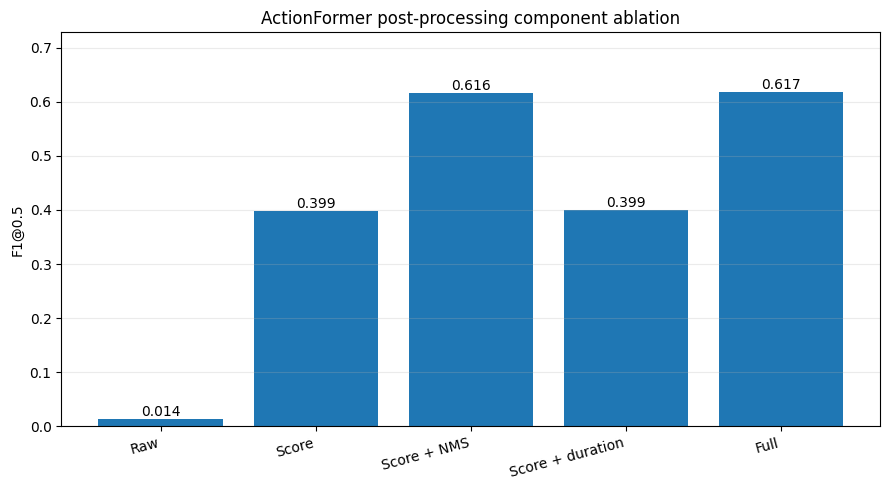

Saved ablation plot -> /content/drive/MyDrive/AML_Project/step_1_results_final/actionformer_postprocessing_ablation_f1.png


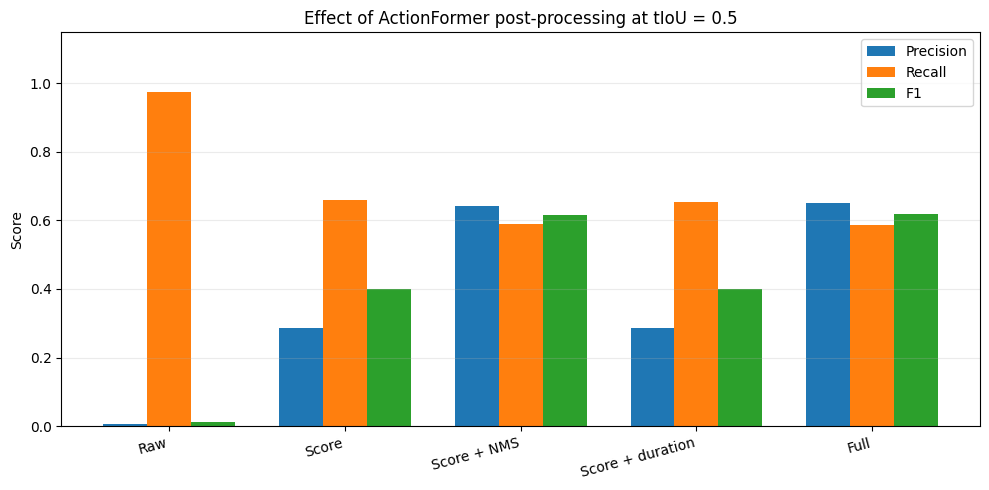

Saved P/R/F1 ablation plot -> /content/drive/MyDrive/AML_Project/step_1_results_final/actionformer_postprocessing_ablation_prf.png


In [10]:
# ==============================================================================
# VISUALIZE POST-PROCESSING COMPONENT ABLATION
# ==============================================================================
# Shows how each post-processing component affects localization performance.
# All parameters were selected on validation and are frozen here on the test set.

import matplotlib.pyplot as plt
import numpy as np

# Keep variants in the methodological order used in the ablation
variant_order = [
    "raw",
    "score",
    "score + NMS",
    "score + duration",
    "full",
]

plot_df = component_ablation_df.loc[variant_order].copy()

# ------------------------------------------------------------------
# Main figure: F1@0.5
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))
values = plot_df["f1@0.5"].values

bars = ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(
    ["Raw", "Score", "Score + NMS", "Score + duration", "Full"],
    rotation=15,
    ha="right",
)
ax.set_ylabel("F1@0.5")
ax.set_title("ActionFormer post-processing component ablation")
ax.set_ylim(0, max(values) * 1.18 if max(values) > 0 else 1)

# Add exact values above bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

ablation_plot_path = os.path.join(
    STEP1_RESULTS_DIR,
    "actionformer_postprocessing_ablation_f1.png",
)
plt.savefig(ablation_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved ablation plot -> {ablation_plot_path}")


# ------------------------------------------------------------------
# Optional second figure: Precision / Recall / F1@0.5
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.25

precision = plot_df["precision@0.5"].values
recall = plot_df["recall@0.5"].values
f1 = plot_df["f1@0.5"].values

ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(
    ["Raw", "Score", "Score + NMS", "Score + duration", "Full"],
    rotation=15,
    ha="right",
)
ax.set_ylabel("Score")
ax.set_title("Effect of ActionFormer post-processing at tIoU = 0.5")
ax.set_ylim(0, max(np.max(precision), np.max(recall), np.max(f1)) * 1.18)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

ablation_prf_plot_path = os.path.join(
    STEP1_RESULTS_DIR,
    "actionformer_postprocessing_ablation_prf.png",
)
plt.savefig(ablation_prf_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved P/R/F1 ablation plot -> {ablation_prf_plot_path}")

## 6. Compare Predicted vs Ground Truth Boundaries

GT and predicted step boundaries for a sample of recordings, drawn as spans on a shared
time axis so drift, merged steps and split steps are visible directly rather than only as
aggregate tIoU scores.

109 held-out test recordings, step-count MAE 3.28.
Showing the lower-quartile, median and upper-quartile recordings by signed step-count error.

  signed step-count error: -4


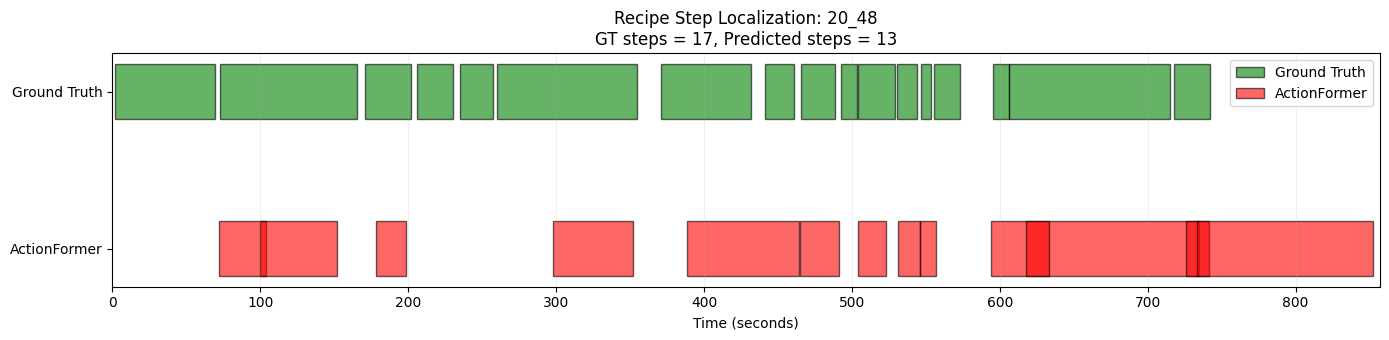

Recording: 20_48
  GT steps:        17
  Predicted steps: 13
  signed step-count error: -1


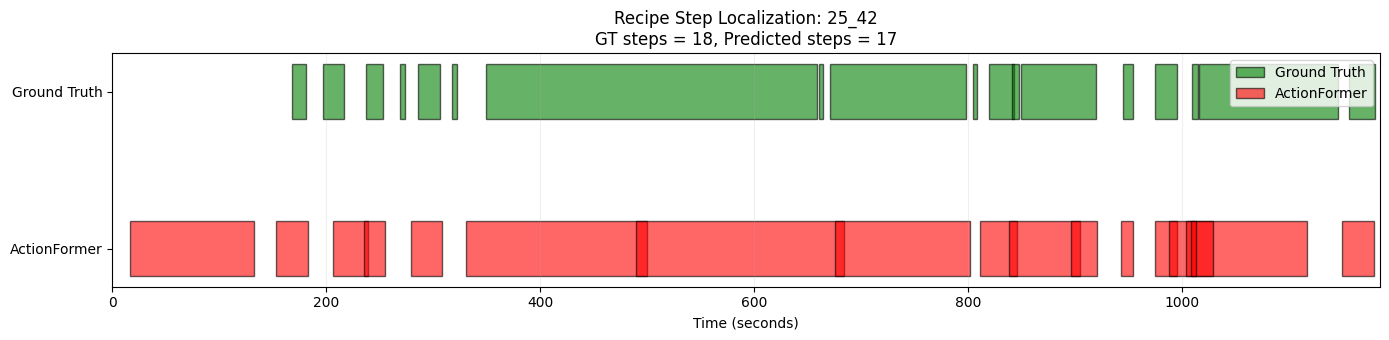

Recording: 25_42
  GT steps:        18
  Predicted steps: 17
  signed step-count error: +1


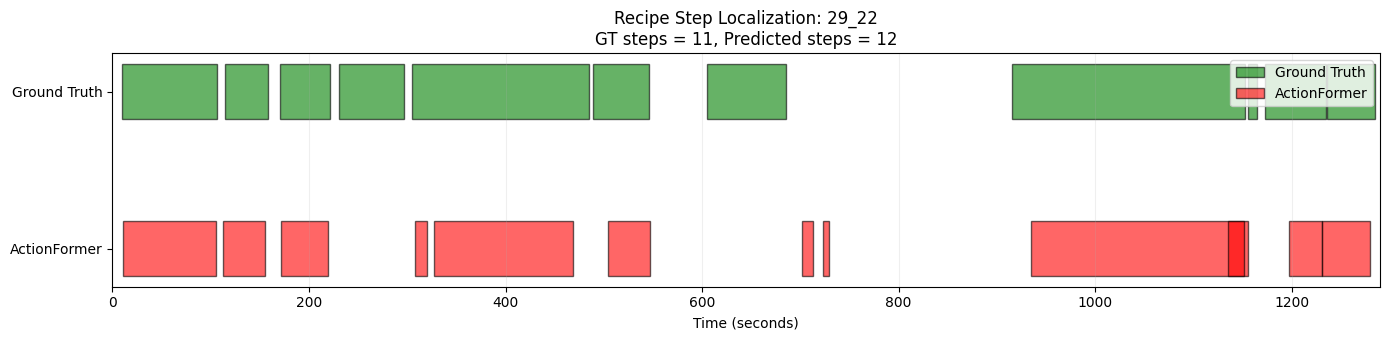

Recording: 29_22
  GT steps:        11
  Predicted steps: 12


In [11]:
import matplotlib.pyplot as plt

def compare_boundaries(rec_id, predictions, gt_annotations):
    """Plot GT and predicted recipe steps on separate horizontal bars."""

    pred_data = predictions[rec_id]

    if isinstance(pred_data, dict) and "steps" in pred_data:
        pred_steps = pred_data["steps"]
    else:
        pred_steps = pred_data

    gt_steps = gt_annotations[rec_id]["steps"]

    # ----------------------------------------------------------
    # Extract valid segments
    # ----------------------------------------------------------

    gt_segments = []

    for step in gt_steps:
        start = float(step["start_time"])
        end = float(step["end_time"])

        if start >= 0 and end > start:
            gt_segments.append((start, end))


    pred_segments = [
        (
            float(step["segment"][0]),
            float(step["segment"][1])
        )
        for step in pred_steps
        if float(step["segment"][1]) > float(step["segment"][0])
    ]


    # ----------------------------------------------------------
    # Plot
    # ----------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 3.5))

    # Ground truth — top row
    for i, (start, end) in enumerate(gt_segments):
        ax.barh(
            y=1,
            width=end - start,
            left=start,
            height=0.35,
            color="green",
            alpha=0.6,
            edgecolor="black",
            label="Ground Truth" if i == 0 else None
        )

    # ActionFormer — bottom row
    for i, (start, end) in enumerate(pred_segments):
        ax.barh(
            y=0,
            width=end - start,
            left=start,
            height=0.35,
            color="red",
            alpha=0.6,
            edgecolor="black",
            label="ActionFormer" if i == 0 else None
        )


    # ----------------------------------------------------------
    # Formatting
    # ----------------------------------------------------------

    ax.set_yticks([0, 1])
    ax.set_yticklabels([
        "ActionFormer",
        "Ground Truth"
    ])

    ax.set_xlabel("Time (seconds)")

    ax.set_title(
        f"Recipe Step Localization: {rec_id}\n"
        f"GT steps = {len(gt_segments)}, "
        f"Predicted steps = {len(pred_segments)}"
    )

    max_time = 0

    if gt_segments:
        max_time = max(
            max_time,
            max(end for _, end in gt_segments)
        )

    if pred_segments:
        max_time = max(
            max_time,
            max(end for _, end in pred_segments)
        )

    ax.set_xlim(0, max_time + 5)

    ax.grid(
        axis="x",
        alpha=0.2
    )

    ax.legend(
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()

    print(f"Recording: {rec_id}")
    print(f"  GT steps:        {len(gt_segments)}")
    print(f"  Predicted steps: {len(pred_segments)}")

predictions_actionformer = predictions_actionformer_final

# Draw from the HELD-OUT TEST split only. Taking the first N keys of the prediction dict
# instead would sample mostly training recordings, where the checkpoint has already seen
# the boundaries it is being praised for - a qualitative figure has to come from the same
# data the quantitative table is scored on.
#
# Within the test split the dict order is still arbitrary, and arbitrary is not the same as
# representative: the first three test recordings include one of the twenty largest
# step-count errors in the dataset. Selecting by quartile of the signed step-count error
# gives one under-segmented, one accurate and one over-segmented recording, each at a
# typical magnitude for its kind - the three failure modes this figure exists to show,
# with the sample neither flattered nor unlucky.
test_ids_with_preds = [
    r for r in splits["test"]
    if r in predictions_actionformer and r in step_annotations
]

count_error = {
    r: len(predictions_actionformer[r]) - len(get_gt_segments_seconds(r))
    for r in test_ids_with_preds
}
ranked = sorted(test_ids_with_preds, key=lambda r: (count_error[r], r))
sample_ids = [
    ranked[len(ranked) // 4],           # under-segmented
    ranked[len(ranked) // 2],           # closest to the correct step count
    ranked[(3 * len(ranked)) // 4],     # over-segmented
]

test_mae = sum(abs(e) for e in count_error.values()) / len(count_error)
print(f"{len(test_ids_with_preds)} held-out test recordings, step-count MAE {test_mae:.2f}.")
print("Showing the lower-quartile, median and upper-quartile recordings by signed "
      "step-count error.\n")
for rec_id in sample_ids:
    print(f"  signed step-count error: {count_error[rec_id]:+d}")
    compare_boundaries(
        rec_id,
        predictions_actionformer,
        step_annotations
    )

In [12]:
# ==============================================================================
# GT VS PREDICTED STEP-COUNT SUMMARY
# ==============================================================================

# The step count is the quantity Substep 4 turns out to be reading, so its error is
# reported per split rather than pooled. Pooling puts the 213 training recordings the
# checkpoint fitted into the same average as the 109 it has never seen, which flatters the
# number: quote the TEST row, and treat the "all" row as a diagnostic only.
split_of = {r: name for name, ids in splits.items() for r in ids}

count_rows = []
for rec_id, preds in predictions_actionformer_final.items():
    if rec_id not in step_annotations:
        continue
    gt_count = len(get_gt_segments_seconds(rec_id))
    pred_count = len(preds)
    count_rows.append({
        "recording_id": rec_id,
        "split": split_of.get(rec_id, "unknown"),
        "gt_steps": gt_count,
        "pred_steps": pred_count,
        "signed_error": pred_count - gt_count,
        "abs_error": abs(pred_count - gt_count),
    })

step_count_df = pd.DataFrame(count_rows)

header = f"{'split':<10}{'n':>6}{'GT mean':>10}{'pred mean':>11}{'MAE':>8}{'signed':>9}"
print(header)
print("-" * len(header))
for name in ["train", "val", "test"]:
    sub = step_count_df[step_count_df["split"] == name]
    if sub.empty:
        continue
    print(f"{name:<10}{len(sub):>6}{sub['gt_steps'].mean():>10.2f}"
          f"{sub['pred_steps'].mean():>11.2f}{sub['abs_error'].mean():>8.2f}"
          f"{sub['signed_error'].mean():>+9.2f}")
print("-" * len(header))
print(f"{'all':<10}{len(step_count_df):>6}{step_count_df['gt_steps'].mean():>10.2f}"
      f"{step_count_df['pred_steps'].mean():>11.2f}{step_count_df['abs_error'].mean():>8.2f}"
      f"{step_count_df['signed_error'].mean():>+9.2f}")

_test_mae = step_count_df[step_count_df["split"] == "test"]["abs_error"].mean()
print(f"\nHeld-out step-count MAE: {_test_mae:.2f} on a mean of "
      f"{step_count_df[step_count_df['split'] == 'test']['gt_steps'].mean():.2f} annotated "
      "steps per recording.")
print("This is the figure to quote. The detector recovers roughly the right number of steps")
print("without being told it, which is what lets the realized graphs of Substep 3 be built")
print("under predicted boundaries at all - and also what leaves part of the step-count")
print("shortcut intact in Substep 4.")

print("\nLargest absolute errors:")
display(
    step_count_df.sort_values("abs_error", ascending=False).head(20).reset_index(drop=True)
)


split          n   GT mean  pred mean     MAE   signed
------------------------------------------------------
train        213     14.02      15.72    1.92    +1.70
val           62     14.26      13.23    2.81    -1.03
test         109     14.15      12.72    3.28    -1.42
------------------------------------------------------
all          384     14.10      14.47    2.45    +0.37

Held-out step-count MAE: 3.28 on a mean of 14.15 annotated steps per recording.
This is the figure to quote. The detector recovers roughly the right number of steps
without being told it, which is what lets the realized graphs of Substep 3 be built
under predicted boundaries at all - and also what leaves part of the step-count
shortcut intact in Substep 4.

Largest absolute errors:


,recording_id,split,gt_steps,pred_steps,signed_error,abs_error
0,16_3,train,23,38,15,15
1,10_46,val,18,4,-14,14
2,23_41,test,24,10,-14,14
3,10_24,test,19,8,-11,11
4,10_47,test,19,9,-10,10
5,15_39,val,18,8,-10,10
6,10_48,test,16,7,-9,9
7,18_49,test,13,22,9,9
8,23_6,train,25,33,8,8
9,5_22,test,16,8,-8,8


split          n   count MAE   mean best tIoU
---------------------------------------------
train        213        1.92            0.891
val           62        2.81            0.539
test         109        3.28            0.520

Boundary quality falls sharply on held-out recordings
(0.891 -> 0.520) while the step COUNT degrades far less
(1.92 -> 3.28). That asymmetry is the mechanism behind Substep 4's
boundary-swap penalty: the graph pipeline reads the number of steps performed, which
largely survives the swap, while everything boundary-dependent does not. Quote the test
row - the train row is here only to size the gap.


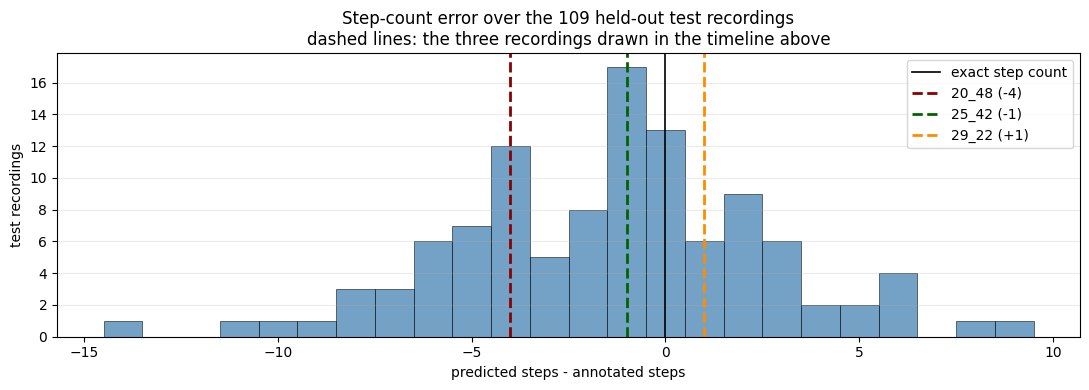

Under-segmented 65, exact 13, over-segmented 31 of 109 test recordings.
Signed error spans -14 to +9. The distribution is left-skewed, so the detector
drops steps more severely than it invents them, and the quartile-selected examples
inherit that asymmetry - do not describe the under- and over-segmented cases as
symmetric failures of equal size.


In [13]:
# ==============================================================================
# HOW WELL DOES THE DETECTOR TRANSFER, AND ARE THE EXAMPLES ABOVE TYPICAL?
# ==============================================================================
# Two questions the timeline figure raises and cannot answer on its own.
#
# 1. Boundary quality is not step-count quality. A recording can have exactly the
#    right number of predicted steps and still place every one of them wrongly, so
#    the count error is reported next to a per-recording mean best tIoU: for each
#    annotated segment, the tIoU of the prediction that overlaps it best.
#
# 2. Reporting either quantity per split is what separates a detector that
#    generalizes from one that has memorized its training recordings. The gap below
#    is large, and it is the mechanism behind the boundary-swap penalty Substep 4
#    measures - which is why it is worth a table of its own rather than a footnote.

def mean_best_tiou(rec_id):
    """Per annotated segment, the tIoU of its best-overlapping prediction."""
    gt_segs = get_gt_segments_seconds(rec_id)
    if not gt_segs:
        return float("nan")
    pred_segs = [(float(p["segment"][0]), float(p["segment"][1]))
                 for p in predictions_actionformer_final.get(rec_id, [])]
    return float(np.mean([
        max((temporal_iou(g, p) for p in pred_segs), default=0.0) for g in gt_segs
    ]))


step_count_df["mean_best_tiou"] = step_count_df["recording_id"].map(mean_best_tiou)

header = f"{'split':<10}{'n':>6}{'count MAE':>12}{'mean best tIoU':>17}"
print(header)
print("-" * len(header))
for name in ["train", "val", "test"]:
    sub = step_count_df[step_count_df["split"] == name]
    if sub.empty:
        continue
    print(f"{name:<10}{len(sub):>6}{sub['abs_error'].mean():>12.2f}"
          f"{sub['mean_best_tiou'].mean():>17.3f}")

_tr = step_count_df[step_count_df["split"] == "train"]
_te = step_count_df[step_count_df["split"] == "test"]

print(f"""
Boundary quality falls sharply on held-out recordings
({_tr['mean_best_tiou'].mean():.3f} -> {_te['mean_best_tiou'].mean():.3f}) while the step COUNT degrades far less
({_tr['abs_error'].mean():.2f} -> {_te['abs_error'].mean():.2f}). That asymmetry is the mechanism behind Substep 4's
boundary-swap penalty: the graph pipeline reads the number of steps performed, which
largely survives the swap, while everything boundary-dependent does not. Quote the test
row - the train row is here only to size the gap.""")

# ------------------------------------------------------------------------------
# Is the three-recording timeline above drawn from a representative place?
# ------------------------------------------------------------------------------
# Three timelines cannot show a distribution, and a reader is entitled to ask whether
# they were chosen to flatter or to alarm. Marking them on the histogram of the whole
# held-out split answers that in one panel, and replaces the alternative of scrolling
# through dozens of individually uninformative plots.
fig, ax = plt.subplots(figsize=(11, 4))
_signed = _te["signed_error"]
_bins = np.arange(_signed.min() - 0.5, _signed.max() + 1.5, 1.0)
ax.hist(_signed, bins=_bins, color="steelblue", alpha=0.75,
        edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=1.2, label="exact step count")

for rec_id, colour in zip(sample_ids, ["darkred", "darkgreen", "darkorange"]):
    ax.axvline(count_error[rec_id], color=colour, linestyle="--", linewidth=2,
               label=f"{rec_id} ({count_error[rec_id]:+d})")

ax.set_xlabel("predicted steps - annotated steps")
ax.set_ylabel("test recordings")
ax.set_title(f"Step-count error over the {len(_te)} held-out test recordings\n"
             "dashed lines: the three recordings drawn in the timeline above")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Under-segmented {int((_signed < 0).sum())}, exact {int((_signed == 0).sum())}, "
      f"over-segmented {int((_signed > 0).sum())} of {len(_te)} test recordings.")
print(f"Signed error spans {int(_signed.min()):+d} to {int(_signed.max()):+d}. The "
      "distribution is left-skewed, so the detector")
print("drops steps more severely than it invents them, and the quartile-selected examples")
print("inherit that asymmetry - do not describe the under- and over-segmented cases as")
print("symmetric failures of equal size.")


## 7. Step embedding extraction and export

The legacy cells below now consume the compatibility alias `predictions_actionformer`, which is guaranteed above to point to the validation-selected final predictions.

In [14]:
# ==============================================================================
# STEP EMBEDDING EXTRACTION: GT vs ActionFormer Predicted Boundaries
# ==============================================================================
import pickle
import numpy as np

def extract_step_embeddings_from_segments(features, segments, pooling='mean'):
    """Extract step-level embeddings by pooling features within predicted segments."""
    step_embeddings = []
    for start, end in segments:
        start = max(0, int(start))
        end = min(len(features), int(end))
        if end <= start:
            continue

        segment_features = features[start:end]
        if pooling == 'mean':
            step_emb = np.mean(segment_features, axis=0)
        elif pooling == 'max':
            step_emb = np.max(segment_features, axis=0)
        else:
            step_emb = np.mean(segment_features, axis=0)

        step_embeddings.append(step_emb)

    if len(step_embeddings) == 0:
        step_embeddings = [np.mean(features, axis=0)]

    return np.array(step_embeddings)


def get_gt_segments(recording_id, step_annotations, fps=1.0):
    """Convert GT annotations to frame-based segments."""
    if recording_id not in step_annotations:
        return None

    steps = step_annotations[recording_id]['steps']
    segments = []
    for step in steps:
        # Skip missing steps. CaptainCook4D marks unannotated steps with negative
        # timestamps, and CaptainCookStepDataset._prepare_recording_step_dictionary
        # skips them the same way ("Ignore missing steps"). Without this filter they
        # become (-1, -1) segments that stay in `segments` and inflate `num_steps`,
        # but are dropped by extract_step_embeddings_from_segments - leaving
        # num_steps larger than the embedding row count in 141 of 384 recordings,
        # so anything zipping segments with embeddings silently misaligns.
        if float(step['start_time']) < 0 or float(step['end_time']) < 0:
            continue
        start_frame = int(float(step['start_time']) * fps)
        end_frame = int(float(step['end_time']) * fps)
        segments.append((start_frame, end_frame))

    return segments


def get_recipe_label_and_id(recording_id, step_annotations):
    """Get recipe ID and error label for a recording with robust fallback."""
    # Default values
    recipe_id = 0
    has_error = 0

    # 1. Robust Recipe ID Extraction
    try:
        parts = recording_id.split('_')
        if len(parts) >= 2:
            recipe_id = int(parts[0])
    except:
        pass

    # Check annotation if available
    ann = step_annotations.get(recording_id, {})
    if recipe_id == 0 and 'recipe_type' in ann:
        recipe_id = ann['recipe_type']

    # 2. Robust Error Label Extraction (Updated to check INSIDE steps)
    # Check top-level first
    if ann.get('has_errors', False) or ann.get('is_error', False) or ann.get('error', False):
        has_error = 1

    # Check step-level (Aggregation)
    if has_error == 0 and 'steps' in ann:
        for step in ann['steps']:
            if step.get('has_errors', False) or step.get('is_error', False):
                has_error = 1
                break

    return int(recipe_id), int(has_error)

print("Step embedding extraction functions updated: Now checking inside steps for errors.")

Step embedding extraction functions updated: Now checking inside steps for errors.


In [15]:
# ==============================================================================
# ACTIONFORMER CHECKPOINT COVERAGE CHECK
# ==============================================================================
# `predictions_actionformer` was produced above by running epoch_032.pth.tar on
# the available EgoVLP features. No released/precomputed CaptainCook4D CSV is used.

missing_actionformer = sorted(
    set(available_recordings) - set(predictions_actionformer.keys())
)
empty_actionformer = sorted(
    rec_id for rec_id, preds in predictions_actionformer.items() if not preds
)

print(f"Available recordings:          {len(available_recordings)}")
print(f"ActionFormer prediction keys:  {len(predictions_actionformer)}")
print(f"Missing prediction keys:       {len(missing_actionformer)}")
print(f"Empty prediction lists:        {len(empty_actionformer)}")
if missing_actionformer:
    print("First missing IDs:", missing_actionformer[:10])
if empty_actionformer:
    print("First empty IDs:", empty_actionformer[:10])


Available recordings:          384
ActionFormer prediction keys:  384
Missing prediction keys:       0
Empty prediction lists:        0


In [16]:
# ==============================================================================
# GENERATE STEP EMBEDDINGS (ActionFormer & GT) - Saved to Drive
# ==============================================================================
# Output format matches extension_step2_verification_baseline.ipynb expectations
# ==============================================================================

import os
import pickle

# 1. Output directories
#
# The two step-embedding pickles are the pipeline handoff, so they go to
# extension_data/ where Substeps 2, 3 and 4 look. OUTPUT_DIR stays pointed at this
# notebook's own artefact folder for the figures below.
OUTPUT_DIR = STEP1_RESULTS_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Outside Colab both names resolve to the same folder; write it once.
HANDOFF_DIRS = list({os.path.realpath(d): d
                     for d in (EXTENSION_DATA_DIR, LOCAL_EXTENSION_DIR)}.values())
for _d in HANDOFF_DIRS:
    os.makedirs(_d, exist_ok=True)


def save_step_embeddings(payload, filename):
    """Write one export to every handoff directory. Returns the paths written."""
    written = []
    for directory in HANDOFF_DIRS:
        path = os.path.join(directory, filename)
        with open(path, 'wb') as f:
            pickle.dump(payload, f)
        written.append(path)
    return written


print(f"Artefacts        : {OUTPUT_DIR}")
print(f"Pipeline handoff : {', '.join(HANDOFF_DIRS)}")

# 2. Helpers
def generate_embeddings_for_method(predictions_dict, method_name, splits, step_annotations):
    """Generate step embeddings using predicted boundaries."""
    data = {}
    recipe_ids_found = set()
    labels_found = set()
    n_skipped = 0

    for split_name, recording_ids in splits.items():
        for rec_id in tqdm(recording_ids, desc=f"{method_name} - {split_name}"):
            features = load_features(rec_id)
            if features is None:
                continue

            # Resolve segments
            final_segments = []
            if rec_id in predictions_dict:
                preds = predictions_dict[rec_id]
                if isinstance(preds, list):
                    for item in preds:
                        # Prefer pre-calculated frame indices if available (ActionFormer)
                        if isinstance(item, dict) and 'segment_frames' in item:
                            final_segments.append(tuple(item['segment_frames']))
                        # Handle raw tuples (GT)
                        elif isinstance(item, tuple):
                            final_segments.append(item)
                        # Fallback for dicts without segment_frames
                        elif isinstance(item, dict) and 'segment' in item:
                             s, e = item['segment']
                             final_segments.append((int(s * FEATURE_FPS), int(e * FEATURE_FPS)))

            # No segments for this recording -> EXCLUDE it. Do not fall back to
            # [(0, len(features))]: that would invent a whole-video "step" rather
            # than preserving the ActionFormer localization result.
            if not final_segments:
                n_skipped += 1
                continue

            # Drop segments that cannot yield an embedding (empty after clamping to
            # the feature array), so `segments`, `num_steps` and `step_embeddings`
            # stay index-aligned. extract_step_embeddings_from_segments silently
            # skips these, which previously left num_steps > len(step_embeddings).
            final_segments = [(a, b) for a, b in final_segments
                              if max(0, int(a)) < min(len(features), int(b))]
            if not final_segments:
                n_skipped += 1
                continue

            # Extract embeddings
            step_embeddings = extract_step_embeddings_from_segments(features, final_segments)
            assert len(step_embeddings) == len(final_segments), (
                f"{rec_id}: {len(step_embeddings)} embeddings for {len(final_segments)} "
                f"segments - these must stay aligned or downstream indexing breaks."
            )

            # Use the robust function
            recipe_id, has_error = get_recipe_label_and_id(rec_id, step_annotations)
            if recipe_id is None: recipe_id = 0

            recipe_ids_found.add(recipe_id)
            labels_found.add(has_error)

            data[rec_id] = {
                'step_embeddings': step_embeddings,
                'recipe_id': recipe_id,
                'recipe_label': has_error,
                'num_steps': len(final_segments),
                'segments': final_segments
            }

    # VERIFICATION
    print(f"\n[VERIFICATION] {method_name}:")
    print(f"  Recordings written: {len(data)} | skipped (no segments): {n_skipped}")
    print(f"  Unique Recipe IDs found: {sorted(list(recipe_ids_found))}")
    print(f"  Unique Labels found: {sorted(list(labels_found))}")
    if len(recipe_ids_found) <= 1 or len(labels_found) <= 1:
        print("  WARNING: Potential data integrity issue (only 1 class/recipe found)!")
    else:
        print("  Data distribution looks valid.")

    return data

print("Generating step embeddings for pipeline integration...")
print("=" * 60)

# Method 1: Ground Truth
print("\n[1/2] Extracting embeddings using GT boundaries...")
gt_predictions = {}
for rec_id in available_recordings:
    # Important: Use correct FPS for GT conversion
    gt_segs = get_gt_segments(rec_id, step_annotations, fps=FEATURE_FPS)
    if gt_segs:
        gt_predictions[rec_id] = gt_segs

gt_data = generate_embeddings_for_method(gt_predictions, "GT", splits, step_annotations)

# `feature_fps` travels with the export because every consumer converts the stored
# segments back to seconds with it. Substep 3 also needs `segments` present and aligned
# with `step_embeddings` to recover the order of execution.
gt_paths = save_step_embeddings({
    'data': gt_data,
    'splits': splits,
    'method': 'ground_truth',
    'description': ('Step boundaries from the CaptainCook4D annotations (oracle): the '
                    'annotation lists only the steps actually performed, so the segment '
                    'count is itself informative about the label.'),
    'feature_fps': FEATURE_FPS,
    'postprocessing': None,
}, "step_embeddings_gt.pkl")
for _p in gt_paths:
    print(f"  Saved to {_p}")

# Method 2: ActionFormer
print("\n[2/2] Extracting embeddings using ActionFormer predictions...")
if 'predictions_actionformer' in globals() and predictions_actionformer:
    af_data = generate_embeddings_for_method(predictions_actionformer, "ActionFormer", splits, step_annotations)

    af_paths = save_step_embeddings({
        'data': af_data,
        'splits': splits,
        'method': 'actionformer',
        'variant': 'trained_checkpoint_cc4d_egovlp_1s',
        'source': ACTIONFORMER_CHECKPOINT,
        'actionformer_repo': ACTIONFORMER_REPO_URL,
        'actionformer_commit': ACTIONFORMER_COMMIT,
        'n_recordings': len(af_data),
        'description': ('Step boundaries from an ActionFormer checkpoint trained on our '
                        'EgoVLP 1s features; post-processing selected on the validation '
                        'split only and frozen.'),
        'feature_fps': FEATURE_FPS,
        'postprocessing': POSTPROCESSING_CONFIG,
    }, "step_embeddings_actionformer.pkl")
    for _p in af_paths:
        print(f"  Saved to {_p}")
else:
    print("  ActionFormer predictions not found! Run generation cell first.")

# The handoff is only real if both files carry what the later substeps read. Checking it
# here costs nothing and turns a silent downstream failure into an immediate one.
for _name in ("step_embeddings_gt.pkl", "step_embeddings_actionformer.pkl"):
    for _dir in HANDOFF_DIRS:
        _path = os.path.join(_dir, _name)
        assert os.path.isfile(_path), f"Handoff file missing: {_path}"
        with open(_path, 'rb') as f:
            _payload = pickle.load(f)
        assert {'data', 'splits'} <= set(_payload), f"{_path}: missing top-level keys"
        _example = next(iter(_payload['data'].values()))
        assert {'step_embeddings', 'segments', 'recipe_id', 'recipe_label', 'num_steps'} \
            <= set(_example), f"{_path}: a record is missing required keys"
        assert len(_example['segments']) == len(_example['step_embeddings']), (
            f"{_path}: segments and step_embeddings are not aligned - Substep 3 recovers "
            f"the order of execution from segments and would read the wrong ones.")

print("\n" + "=" * 60)
print("PIPELINE INTEGRATION COMPLETE")
print(f"Substeps 2, 3 and 4 read these two files from {EXTENSION_DATA_DIR}")

Artefacts        : /content/drive/MyDrive/AML_Project/step_1_results_final
Pipeline handoff : /content/drive/MyDrive/AML_Project/extension_data, /content/code/extension_data
Generating step embeddings for pipeline integration...

[1/2] Extracting embeddings using GT boundaries...


GT - test: 100%|██████████| 109/109 [00:00<00:00, 290.20it/s]



[VERIFICATION] GT:
  Recordings written: 384 | skipped (no segments): 0
  Unique Recipe IDs found: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29]
  Unique Labels found: [0, 1]
  Data distribution looks valid.
  Saved to /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl
  Saved to /content/code/extension_data/step_embeddings_gt.pkl

[2/2] Extracting embeddings using ActionFormer predictions...


ActionFormer - test: 100%|██████████| 109/109 [00:00<00:00, 351.12it/s]



[VERIFICATION] ActionFormer:
  Recordings written: 384 | skipped (no segments): 0
  Unique Recipe IDs found: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 29]
  Unique Labels found: [0, 1]
  Data distribution looks valid.
  Saved to /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_actionformer.pkl
  Saved to /content/code/extension_data/step_embeddings_actionformer.pkl

PIPELINE INTEGRATION COMPLETE
Substeps 2, 3 and 4 read these two files from /content/drive/MyDrive/AML_Project/extension_data



Step Embedding Statistics

Comparison: GT vs ActionFormer
Common recordings: 384

Number of Steps:
  GT:         mean=14.1, std=4.4
  ActionFormer: mean=14.5, std=5.5

Correlation (GT vs ActionFormer step counts): 0.786


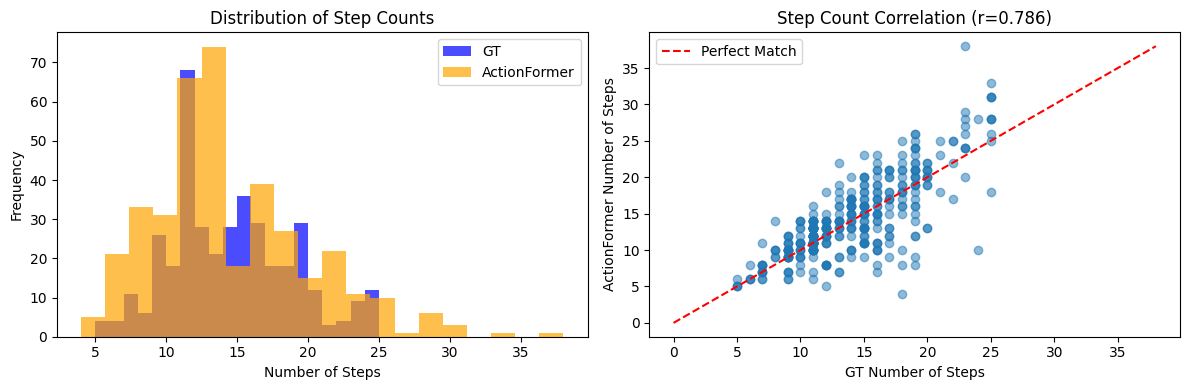

In [17]:
# ==============================================================================
# COMPARISON: GT vs ActionFormer Step Embeddings Statistics
# ==============================================================================

import matplotlib.pyplot as plt

def compare_embedding_stats(gt_data, pred_data, method_name):
    """Compare statistics of step embeddings between GT and predicted boundaries."""

    # Get common recordings
    common_recs = set(gt_data.keys()) & set(pred_data.keys())

    gt_num_steps = []
    pred_num_steps = []

    for rec_id in common_recs:
        gt_num_steps.append(gt_data[rec_id]['num_steps'])
        pred_num_steps.append(pred_data[rec_id]['num_steps'])

    print(f"\n{'='*60}")
    print(f"Comparison: GT vs {method_name}")
    print(f"{'='*60}")
    print(f"Common recordings: {len(common_recs)}")
    print(f"\nNumber of Steps:")
    print(f"  GT:         mean={np.mean(gt_num_steps):.1f}, std={np.std(gt_num_steps):.1f}")
    print(f"  {method_name}: mean={np.mean(pred_num_steps):.1f}, std={np.std(pred_num_steps):.1f}")

    # Correlation
    corr = np.corrcoef(gt_num_steps, pred_num_steps)[0, 1]
    print(f"\nCorrelation (GT vs {method_name} step counts): {corr:.3f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(gt_num_steps, bins=20, alpha=0.7, label='GT', color='blue')
    axes[0].hist(pred_num_steps, bins=20, alpha=0.7, label=method_name, color='orange')
    axes[0].set_xlabel('Number of Steps')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Step Counts')
    axes[0].legend()

    # Scatter
    axes[1].scatter(gt_num_steps, pred_num_steps, alpha=0.5)
    max_val = max(max(gt_num_steps), max(pred_num_steps))
    axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect Match')
    axes[1].set_xlabel('GT Number of Steps')
    axes[1].set_ylabel(f'{method_name} Number of Steps')
    axes[1].set_title(f'Step Count Correlation (r={corr:.3f})')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'step_comparison_gt_vs_{method_name.lower()}.png'), dpi=150)
    plt.show()

    return corr


# Run comparison if data is available
if 'gt_data' in dir() and gt_data:
    print("\nStep Embedding Statistics")

    if 'af_data' in dir() and af_data:
        compare_embedding_stats(gt_data, af_data, "ActionFormer")

    if 'cl_data' in dir() and cl_data:
        compare_embedding_stats(gt_data, cl_data, "Clustering")
else:
    print("Run the embedding extraction cell first")

Evaluating segment localization on 109 test recordings...

tIoU ≥ 0.1 | Precision=0.8089 | Recall=0.7276 | F1=0.7661
tIoU ≥ 0.2 | Precision=0.7916 | Recall=0.7121 | F1=0.7497
tIoU ≥ 0.3 | Precision=0.7592 | Recall=0.6829 | F1=0.7190
tIoU ≥ 0.4 | Precision=0.7138 | Recall=0.6420 | F1=0.6760
tIoU ≥ 0.5 | Precision=0.6518 | Recall=0.5863 | F1=0.6173
tIoU ≥ 0.6 | Precision=0.5544 | Recall=0.4987 | F1=0.5251
tIoU ≥ 0.7 | Precision=0.4340 | Recall=0.3904 | F1=0.4111


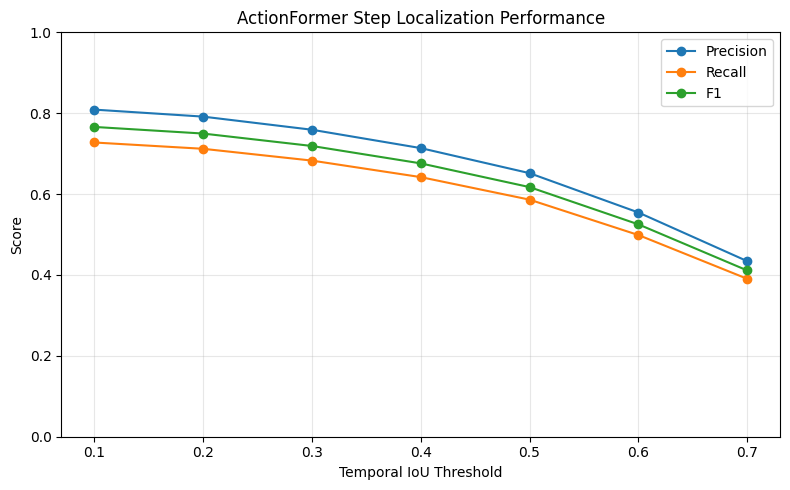


Saved report figure to:
/content/drive/MyDrive/AML_Project/step_1_results_final/actionformer_tiou_performance.png


In [18]:
# ==============================================================================
# REPORT RESULTS 1: Temporal Localization Performance at Multiple tIoU Thresholds
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# The helpers this report needs already exist in section 3: `temporal_iou`,
# `get_gt_segments_seconds` and `greedy_match_segments`. Only the one genuinely new
# helper is defined here, so this cell does not shadow the section-3 versions.


def get_pred_segments_seconds(rec_id):
    """Post-processed ActionFormer segments for one recording, in seconds."""
    segments = []
    for pred in predictions_actionformer.get(rec_id, []):
        if isinstance(pred, dict) and "segment" in pred:
            start, end = float(pred["segment"][0]), float(pred["segment"][1])
            if end > start:
                segments.append((start, end))
    return segments


# Evaluate ONLY the test split
thresholds = np.arange(0.1, 0.8, 0.1)

precision_values = []
recall_values = []
f1_values = []

test_ids = [
    rec_id for rec_id in splits["test"]
    if rec_id in predictions_actionformer and rec_id in step_annotations
]

print(f"Evaluating segment localization on {len(test_ids)} test recordings...")
print()

for threshold in thresholds:

    total_tp = 0
    total_predictions = 0
    total_gt = 0

    for rec_id in test_ids:

        pred_segments = get_pred_segments_seconds(rec_id)
        gt_segments = get_gt_segments_seconds(rec_id)

        tp = greedy_match_segments(
            pred_segments,
            gt_segments,
            threshold
        )

        total_tp += tp
        total_predictions += len(pred_segments)
        total_gt += len(gt_segments)

    precision = (
        total_tp / total_predictions
        if total_predictions > 0 else 0
    )

    recall = (
        total_tp / total_gt
        if total_gt > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )

    precision_values.append(precision)
    recall_values.append(recall)
    f1_values.append(f1)

    print(
        f"tIoU ≥ {threshold:.1f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )


# ------------------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    precision_values,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recall_values,
    marker="o",
    label="Recall"
)

plt.plot(
    thresholds,
    f1_values,
    marker="o",
    label="F1"
)

plt.xlabel("Temporal IoU Threshold")
plt.ylabel("Score")
plt.title("ActionFormer Step Localization Performance")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

tiou_plot_path = os.path.join(
    OUTPUT_DIR,
    "actionformer_tiou_performance.png"
)

plt.savefig(
    tiou_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved report figure to:\n{tiou_plot_path}")